## Этот ноутбук предназначен для объединения всех частей датасета в единый файл и для интепретации структуры бенчмарка.

In [1]:
%pip install gspread pandas google-auth

Note: you may need to restart the kernel to use updated packages.


In [70]:
import gspread
import pandas as pd
from google.oauth2.service_account import Credentials

# === CONFIG ===
SPREADSHEET_ID = "1EHbAK4dtwhABDo4IksOimeP_QPWF_Qn-s3U803RD0iI"
SERVICE_ACCOUNT_FILE = "adllm2024-668f7fc54a20.json"
OUTPUT_CSV = "parsed_exam.csv"

# === AUTH ===
scopes = [
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive"
]

credentials = Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE,
    scopes=scopes
)

gc = gspread.authorize(credentials)

# === OPEN SPREADSHEET ===
sh = gc.open_by_key(SPREADSHEET_ID)

all_dfs = []

# === ITERATE OVER ALL SHEETS ===
for worksheet in sh.worksheets():
    values = worksheet.get_all_values()

    # skip sheets that are too small
    if len(values) < 3:
        continue

    # headers start from 3rd row (index 2)
    headers = values[2]

    # data starts from 4th row
    data = values[3:]

    if not data:
        continue

    df = pd.DataFrame(data, columns=headers)

    # optional: drop fully empty rows
    df = df.dropna(how="all")

    all_dfs.append(df)

# === CONCAT & SAVE ===
if not all_dfs:
    raise ValueError("No data found in any sheet.")

final_df = pd.concat(all_dfs, ignore_index=True)
final_df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved {len(final_df)} rows to {OUTPUT_CSV}")

Saved 112 rows to parsed_exam.csv


In [5]:
final_df = pd.read_csv("parsed_exam.csv")

In [6]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   exam_id           112 non-null    object 
 1   page_id           112 non-null    object 
 2   question_id       112 non-null    object 
 3   question_type     112 non-null    object 
 4   question_text     94 non-null     object 
 5   answer_type       94 non-null     object 
 6   canonical_answer  94 non-null     object 
 7   max_score         104 non-null    float64
dtypes: float64(1), object(7)
memory usage: 7.1+ KB


In [7]:
# убрать skip
final_df = final_df.query("question_type != 'skip'")

In [8]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 0 to 110
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   exam_id           94 non-null     object 
 1   page_id           94 non-null     object 
 2   question_id       94 non-null     object 
 3   question_type     94 non-null     object 
 4   question_text     94 non-null     object 
 5   answer_type       94 non-null     object 
 6   canonical_answer  94 non-null     object 
 7   max_score         94 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.6+ KB


In [9]:
final_df['question_type'] = 'text'

In [10]:
final_df["max_score"] = final_df["max_score"].astype('int64')

In [11]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 0 to 110
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   exam_id           94 non-null     object
 1   page_id           94 non-null     object
 2   question_id       94 non-null     object
 3   question_type     94 non-null     object
 4   question_text     94 non-null     object
 5   answer_type       94 non-null     object
 6   canonical_answer  94 non-null     object
 7   max_score         94 non-null     int64 
dtypes: int64(1), object(7)
memory usage: 6.6+ KB


In [3]:
synthesis_df = pd.read_csv(
    "../../benchmark/Full_synthesis.csv")
msms_df = pd.read_csv(
    "../../benchmark/msms_structure_prediction.csv")

In [13]:
synthesis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   exam_id           14 non-null     object
 1   page_id           14 non-null     int64 
 2   question_id       14 non-null     int64 
 3   question_type     14 non-null     object
 4   question_text     14 non-null     object
 5   answer_type       14 non-null     object
 6   canonical_answer  14 non-null     object
 7   max_score         14 non-null     int64 
dtypes: int64(3), object(5)
memory usage: 1.0+ KB


In [14]:
msms_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   exam_id           10 non-null     object
 1   page_id           10 non-null     int64 
 2   question_id       10 non-null     int64 
 3   question_type     10 non-null     object
 4   question_text     10 non-null     object
 5   answer_type       10 non-null     object
 6   canonical_answer  10 non-null     object
 7   max_score         10 non-null     int64 
dtypes: int64(3), object(5)
memory usage: 768.0+ bytes


In [15]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 0 to 110
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   exam_id           94 non-null     object
 1   page_id           94 non-null     object
 2   question_id       94 non-null     object
 3   question_type     94 non-null     object
 4   question_text     94 non-null     object
 5   answer_type       94 non-null     object
 6   canonical_answer  94 non-null     object
 7   max_score         94 non-null     int64 
dtypes: int64(1), object(7)
memory usage: 6.6+ KB


In [16]:
df_all = pd.concat([final_df, synthesis_df, msms_df], ignore_index=True)

In [17]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   exam_id           118 non-null    object
 1   page_id           118 non-null    object
 2   question_id       118 non-null    object
 3   question_type     118 non-null    object
 4   question_text     118 non-null    object
 5   answer_type       118 non-null    object
 6   canonical_answer  118 non-null    object
 7   max_score         118 non-null    int64 
dtypes: int64(1), object(7)
memory usage: 7.5+ KB


In [18]:
df_all.to_csv("benchmark_v1_0.csv", index=False)

In [19]:
df_all.to_json(path_or_buf="benchmark_v1_0.jsonl",
               orient="records", lines=True, force_ascii=False)

## Аналитика бенчмарка

In [20]:
import json
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv(
    'benchmark_v1_0.csv')

In [29]:
manual_df = pd.read_csv("parsed_exam.csv")

raw_df = pd.concat([manual_df, synthesis_df, msms_df], ignore_index=True)

In [30]:
synthesis_df.shape

(14, 8)

### 1. Общая характеристика датасета

In [31]:
raw_df.shape

(136, 8)

In [32]:
df.shape

(118, 8)

In [33]:
answer_counts = df["answer_type"].value_counts().sort_values(ascending=False)
answer_counts

answer_type
full_synthesis               36
structure                    26
text                         17
msms_structure_prediction    10
single_choice                 9
ordering                      9
reaction_description          6
multiple_choice               4
property_determination        1
Name: count, dtype: int64

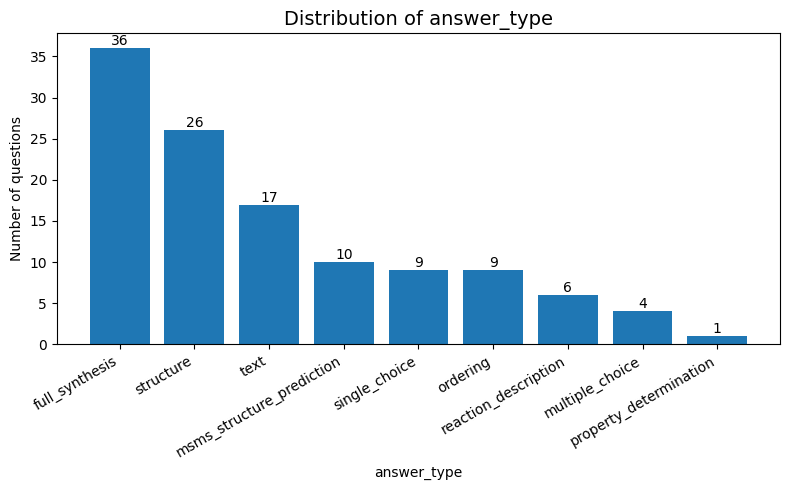

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(answer_counts.index, answer_counts.values)

plt.title("Distribution of answer_type", fontsize=14)
plt.xlabel("answer_type")
plt.ylabel("Number of questions")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [138]:
total_score = df["max_score"].sum()
total_score

681

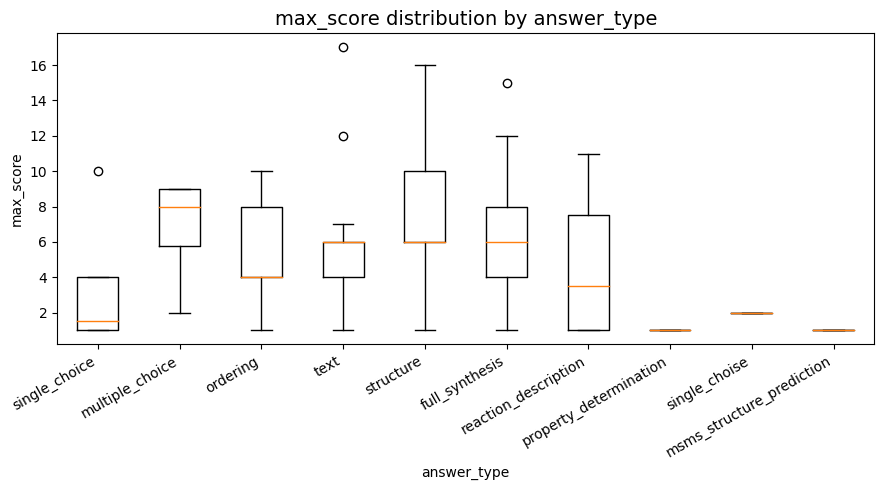

In [140]:
plt.figure(figsize=(9, 5))

answer_types = df["answer_type"].unique()
data = [
    df[df["answer_type"] == at]["max_score"]
    for at in answer_types
]

plt.boxplot(data, labels=answer_types, showfliers=True)

plt.title("max_score distribution by answer_type", fontsize=14)
plt.xlabel("answer_type")
plt.ylabel("max_score")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

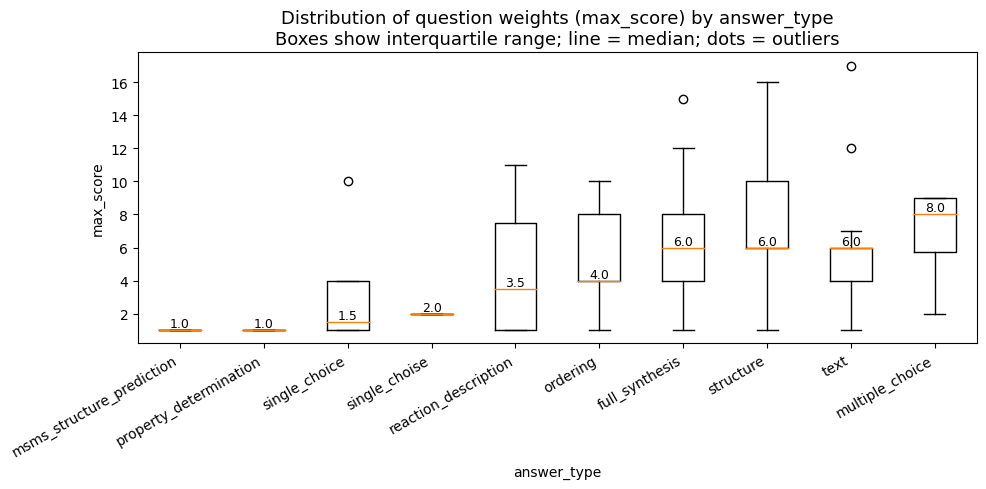

In [ ]:
import numpy as np

grouped = df.groupby("answer_type")["max_score"]

medians = grouped.median().sort_values()
answer_types = medians.index.tolist()
data = [grouped.get_group(at).values for at in answer_types]

plt.figure(figsize=(10, 5))
bp = plt.boxplot(data, labels=answer_types, showfliers=True)

for i, median in enumerate(medians.values):
    plt.text(
        i + 1,
        median,
        f"{median:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    "Distribution of question weights (max_score) by answer_type\n"
    "Boxes show interquartile range; line = median; dots = outliers",
    fontsize=13
)
plt.xlabel("answer_type")
plt.ylabel("max_score")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

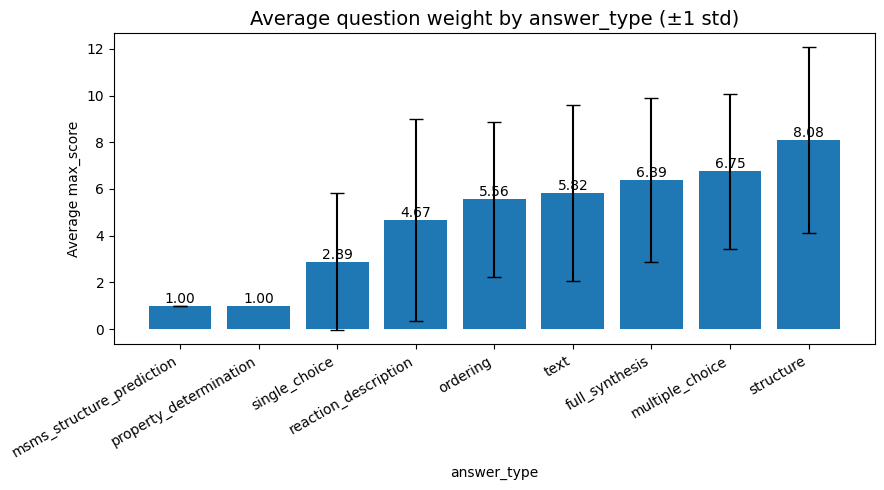

In [36]:
stats = df.groupby("answer_type")["max_score"].agg(
    ["mean", "std"]).sort_values("mean")

plt.figure(figsize=(9, 5))
plt.bar(
    stats.index,
    stats["mean"],
    yerr=stats["std"],
    capsize=5
)

plt.title("Average question weight by answer_type (±1 std)", fontsize=14)
plt.xlabel("answer_type")
plt.ylabel("Average max_score")

for i, v in enumerate(stats["mean"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [141]:
score_by_type = (
    df.groupby("answer_type")["max_score"]
    .sum()
    .sort_values(ascending=False)
)

score_by_type

answer_type
full_synthesis               230
structure                    210
text                          99
ordering                      50
reaction_description          28
multiple_choice               27
single_choice                 24
msms_structure_prediction     10
single_choise                  2
property_determination         1
Name: max_score, dtype: int64

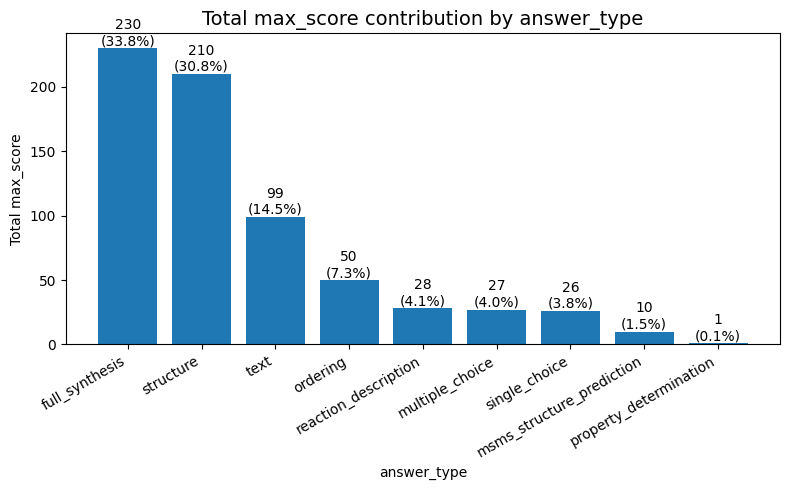

In [35]:
score_by_type = df.groupby("answer_type")[
    "max_score"].sum().sort_values(ascending=False)
total_score = score_by_type.sum()

plt.figure(figsize=(8, 5))
bars = plt.bar(score_by_type.index, score_by_type.values)

plt.title("Total max_score contribution by answer_type", fontsize=14)
plt.xlabel("answer_type")
plt.ylabel("Total max_score")

for bar, value in zip(bars, score_by_type.values):
    percent = value / total_score * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{int(value)}\n({percent:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [155]:
raw_df.shape

(136, 8)

In [156]:
missing_max_score = raw_df["max_score"].isna().sum()
total_raw = len(raw_df)

missing_max_score, total_raw

(8, 136)

In [157]:
pd.DataFrame({
    "Metric": ["Total questions", "Missing max_score"],
    "Value": [total_raw, missing_max_score]
})

,Metric,Value
0,Total questions,136
1,Missing max_score,8
